# Decision trees

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_circles, make_moons, load_breast_cancer, make_swiss_roll, load_iris
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA, KernelPCA
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import MDS, TSNE
from sklearn.tree import DecisionTreeClassifier, plot_tree
from collections import Counter
import time


In [3]:
def entropy(y):
    """Энтропия Шеннона"""
    probs = np.bincount(y) / len(y)
    probs = probs[probs > 0]  # Избегаем log(0)
    return -np.sum(probs * np.log2(probs))

def gini(y):
    """Критерий Джини"""
    pass # TODO

def misclassification_error(y):
    """Ошибка классификации"""
    probs = np.bincount(y) / len(y)
    return 1 - np.max(probs) if len(probs) > 0 else 0

In [4]:
def information_gain(y_parent, y_left, y_right, criterion_func):
    """Расчет Information Gain для заданного разбиения"""
    w_left = len(y_left) / len(y_parent)
    w_right = len(y_right) / len(y_parent)

    gain = criterion_func(y_parent) - (w_left * criterion_func(y_left) + 
                                       w_right * criterion_func(y_right))
    return gain

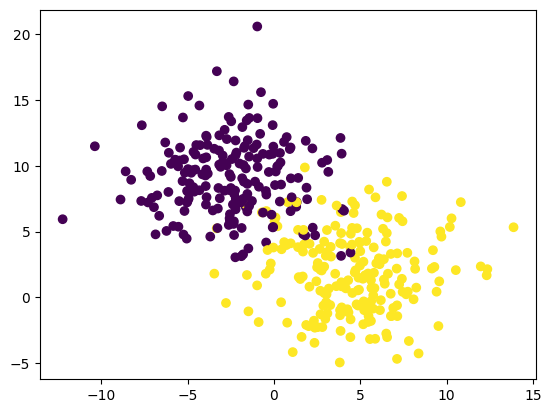

In [5]:
X, y = make_blobs(
    n_samples=400,
    centers=2,
    cluster_std=3,
    random_state=42
)

x1 = X[:, 0]
x2 = X[:, 1]

plt.scatter(x1, x2, c=y)

In [6]:
# example: split x1 by 0
X, y = make_blobs(n_samples=400, centers=2, cluster_std=3, random_state=42)
x1 = X[:, 0]

# Разделение
mask = x1 < 0
y_left = y[mask]
y_right = y[~mask]

# --- Корректные расчеты (передаем y, а не x1) ---
print(f"Entropy full: {entropy(y):.4f}")
print(f"Entropy right: {entropy(y_right):.4f}")
print(f"Entropy left: {entropy(y_left):.4f}")
print(f"Information gain (Entropy): {information_gain(y, y_left, y_right, entropy):.4f}")

Entropy full: 1.0000
Entropy right: 0.6321
Entropy left: 0.4138
Information gain (Entropy): 0.4661


In [7]:
# task
# plot information gain for all possible split of data by x1
# hint: start by sorting values of x1

In [9]:
# task 2
# add entropy of left and right parts to plot

In [11]:
# task 3
# find best split on x1, plot it
# hint: to plot vertical line use axvline

In [14]:
def find_best_split(X, y, criterion_func=entropy):
    """
    Находит самый лучший сплит среди всех имеющихся признаков.
    """
    best_overall_gain = -1
    best_feature_idx = None
    best_threshold = None
    
    n_features = X.shape[1]

    for feature_idx in range(n_features):
        x_current = X[:, feature_idx]
        threshold, gain = find_best_split_r1(x_current, y, criterion_func)

        if gain > best_overall_gain:
            best_overall_gain = gain
            best_feature_idx = feature_idx
            best_threshold = threshold
            
    return best_feature_idx, best_threshold

# Пример вызова:
best_j, best_t = find_best_split(X, y, entropy)
print(f"Best split is along x{best_j+1} with threshold {best_t:.4f}")


Best split is along x2 with threshold 4.4697


**solution idea from lecture**

```python
def build_tree(X, y, criterion_func=entropy, stop=None):
    if stop is not None:
        if stop(X):
            return Node(is_leaf=True, answer=ans(y))
    j,t = best_split(X, y, criterion_func)
    X_left, X_right = split(X, j, t)
    return Node(is_leaf=False, feature=j, threshold=t,
                left=build_tree(X_left, y, criterion_func, stop),
                right=build_tree(X_right, y, criterion_func, stop))
```

In [15]:
class Node:
    def __init__(self, is_leaf=False, feature=None, threshold=None, left=None, right=None, answer=None):
        self.is_leaf = is_leaf
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.answer = answer

In [16]:
def split(X, y, j, t):
    """
    Разделяет выборку на две части по j и t
    """
    left_mask = X[:, j] <= t
    right_mask = ~left_mask
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

In [17]:
def classification_answer(y):
    """
    Возвращает самый частый класс в текущем узле
    """
    if len(y) == 0:
        return None
    return Counter(y).most_common(1)[0][0]

In [18]:
def stop_by_depth(max_depth):
    """
    Функция, которая создает функцию остановки по фиксированной глубине дерева
    """
    def check(X, y, depth):
        return depth >= max_depth
    return check

In [27]:
def build_tree(X, y, criterion_func=entropy, stop=None, ans=classification_answer, depth=0):
    if stop is not None:
        if stop(X, y, depth):
            return Node(is_leaf=True, answer=ans(y))

    split_result = find_best_split(X, y, criterion_func)
    if split_result is None:
        return Node(is_leaf=True, answer=Counter(y).most_common(1)[0][0])

    j, t = split_result
    X_l, y_l, X_r, y_r = split(X, y, j, t)
    if len(y_l) == 0 or len(y_r) == 0:
        return Node(is_leaf=True, answer=ans(y))

    return Node(
        is_leaf=False, 
        feature=j, 
        threshold=t,
        left=build_tree(X_l, y_l, criterion_func, stop, ans, depth + 1),
        right=build_tree(X_r, y_r, criterion_func, stop, ans, depth + 1)
    )

In [26]:
stop_func = stop_by_depth(max_depth=2)
ans_func = classification_answer

root_node = build_tree(
    X, y, 
    criterion_func=entropy, 
    stop=stop_func, 
    ans=ans_func
)

print(root_node.feature)
print(root_node.threshold)


1
4.469744454140729


In [30]:
class MyDecisionTree:
    def __init__(self, criterion_func, stop_func, ans_func):
        self.criterion_func = criterion_func
        self.stop_func = stop_func
        self.ans_func = ans_func
        self.root = None

    def fit(self, X, y):
        self.root = build_tree(
            X, y, 
            criterion_func=self.criterion_func, 
            stop=self.stop_func, 
            ans=self.ans_func
        )
        return self

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

    def _predict_one(self, x, node):
        if node.is_leaf:
            return node.answer
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

In [44]:
def plot_tree_boundaries(clf, X, y, feature_names, target_names, title="Decision Boundaries", ax=None):
    """
    Визуализирует разделяющие области классификатора
    """
    if not ax:
        fig, ax = plt.subplots(figsize=(10, 6))

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid_points)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis', s=40)
    
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    
    handles, _ = scatter.legend_elements()
    ax.legend(handles, target_names, loc="lower right", title="Classes")
    
    return ax

<Figure size 1000x600 with 0 Axes>

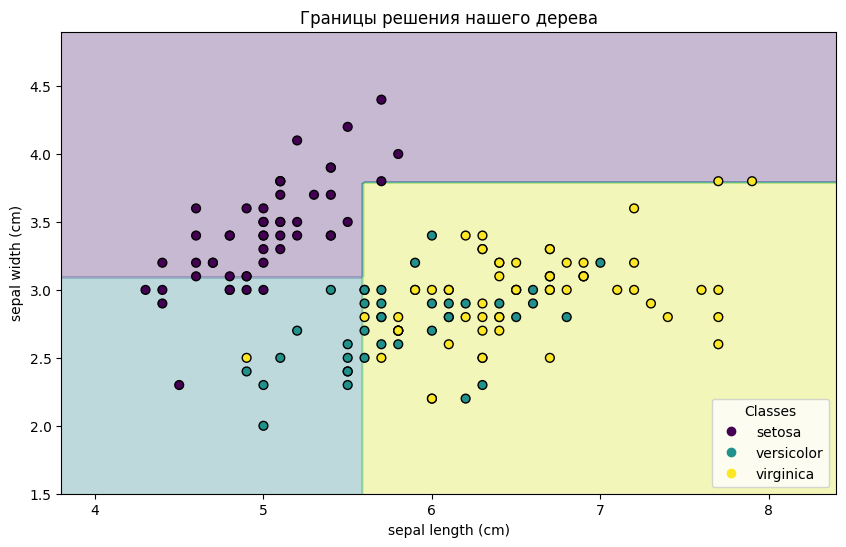

In [40]:
# prepare data
iris = load_iris()
x1, x2 = 0, 1
X = iris.data[:, [x1, x2]]
y = iris.target

# init model and train
stop_func = stop_by_depth(max_depth=2)
ans_func = classification_answer

clf = MyDecisionTree(entropy, stop_func, ans_func)
clf.fit(X, y)

plt.figure(figsize=(10, 6))
plot_tree_boundaries(
    clf, X, y,
    feature_names=[iris.feature_names[x1],iris.feature_names[x2]], 
    target_names=iris.target_names,
    title="Границы решения нашего дерева"
)
plt.show()

<Figure size 1000x600 with 0 Axes>

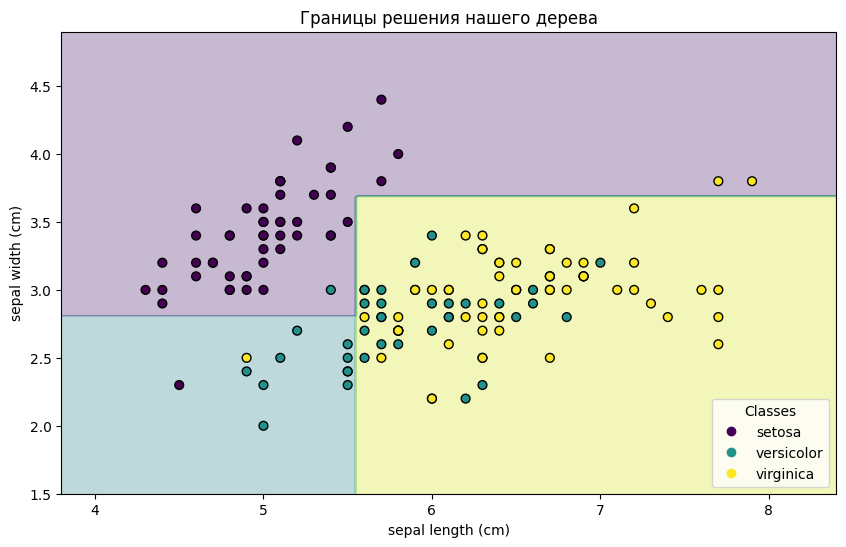

In [42]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=2)
clf.fit(X, y)

plt.figure(figsize=(10, 6))
plot_tree_boundaries(
    clf, X, y,
    feature_names=[iris.feature_names[x1],iris.feature_names[x2]], 
    target_names=iris.target_names,
    title="Границы решения нашего дерева"
)
plt.show()

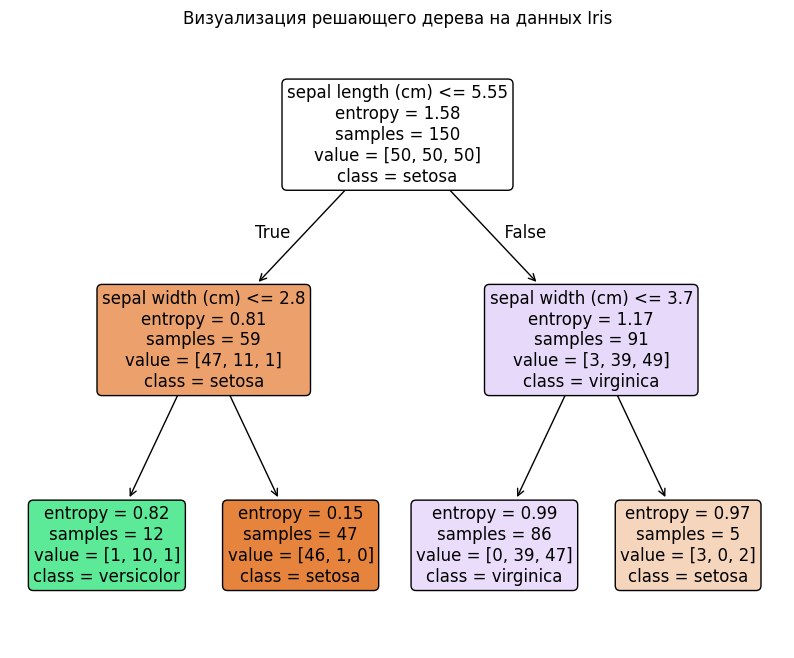

In [ ]:
plt.figure(figsize=(10, 8))
plot_tree(
    clf,
    feature_names=[iris.feature_names[x1],iris.feature_names[x2]],
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=12,
    precision=2
)
plt.title("Визуализация решающего дерева на данных Iris")
plt.show()

In [45]:
clf.feature_importances_

array([0.63978588, 0.36021412])